In [1]:
from pathlib import Path
import itertools
import collections

import numpy as np
import matplotlib.pyplot as plt

/home/fuchs/software/miniconda3/envs/cours-python2/lib/python3.13/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


# Préparer données.

Toute cette partie vous montre comment les données ont été préparées afin de générer le fichier `freq_nucl.dat`. La fonction `lit_genbank()` renvoie la séquence sous forme de str. La cellule du dessus compte calcule les fréquences pour chaque génome (on s'aide pour ça de `collections.Counter()` comme vu ce matin, et crée le fameux fichier `freq_nucl.dat`.

In [2]:
def lit_genbank(nom_genbank):
    seq = ""
    is_seq = False
    with open(nom_genbank, "r") as fichier_genbank:
        for ligne in fichier_genbank:
            if ligne.startswith("//"):
                is_seq = False
            if is_seq:
                seq += ligne[10:-1].replace(" ", "")
            if ligne.startswith("ORIGIN"):
                is_seq = True
    return seq

In [3]:
list_of_genomes = []
with open("freq_nucl.dat", "w") as f:
    line = "genome "
    line += " ".join([f"{a}" for a in "atgc"])    
    f.write(f"{line}\n")
    for genome_filename in Path().glob("genomes/*"):
        list_of_genomes.append(str(genome_filename).replace("genomes/", "").split(".")[0])
        seq = lit_genbank(genome_filename)
        compteur_mots_1lettre = collections.Counter(seq)
        print(f"{genome_filename}, {len(seq)} nucl --> extracted")
        freqs = [compteur_mots_1lettre[base]/len(seq) for base in "atgc"]
        line = f"{str(genome_filename)} "
        line += " ".join([str(freq) for freq in freqs])
        f.write(f"{line}\n")

print(list_of_genomes)

genomes/Bacillus_Subtilis.gbk, 4215606 nucl --> extracted
genomes/Candida_glabrata.gbk, 992211 nucl --> extracted
genomes/Escherichia_Coli.gbk, 4641652 nucl --> extracted
genomes/Herpes_Cercopitheque.gbk, 156789 nucl --> extracted
genomes/Herpes_Humain.gbk, 152261 nucl --> extracted
genomes/SARS_COV_2.gbk, 29903 nucl --> extracted
genomes/SARS_COV_Tor2.gbk, 29751 nucl --> extracted
genomes/Saccharomyces.gbk, 230218 nucl --> extracted
genomes/Staphylococcus_Aureus.gbk, 2878529 nucl --> extracted
['Bacillus_Subtilis', 'Candida_glabrata', 'Escherichia_Coli', 'Herpes_Cercopitheque', 'Herpes_Humain', 'SARS_COV_2', 'SARS_COV_Tor2', 'Saccharomyces', 'Staphylococcus_Aureus']


# Plot data.
L'énoncé de l'exercice commence à partir d'ici.

In [4]:
# Load data : rows = organism, cols = dinuc).
data = np.loadtxt("freq_nucl.dat", skiprows=1, usecols=range(1, 5))
print(data)
data.shape

[[0.28182733 0.28302858 0.21707721 0.21806687]
 [0.30570111 0.30850998 0.1929388  0.19285011]
 [0.24619295 0.24589995 0.25366766 0.25423944]
 [0.12831895 0.12711989 0.37536434 0.36919682]
 [0.15920032 0.15795246 0.34488805 0.33795916]
 [0.29943484 0.32083737 0.19606728 0.1836605 ]
 [0.28506605 0.3073174  0.2079594  0.19965715]
 [0.30334726 0.30395104 0.19879419 0.19390751]
 [0.33460667 0.33661533 0.16488665 0.16389135]]


(9, 4)

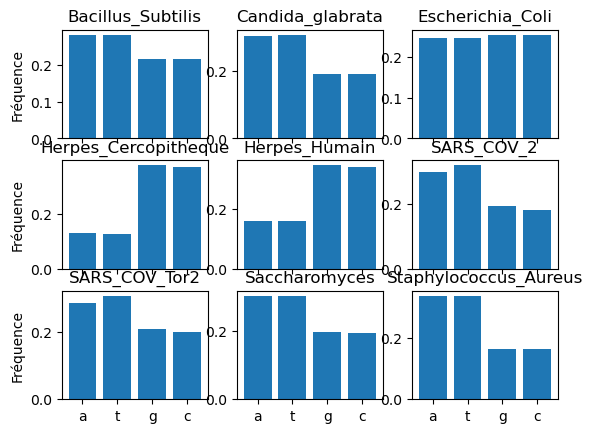

In [5]:
# Ici on fait un barplot de chaque génome.
fig, axs = plt.subplots(3, 3)
count = 0
for i, j in itertools.product(range(3), range(3)):
    axs[i, j].bar(range(4), data[count])
    # Set title.
    axs[i, j].set_title(f"{list_of_genomes[count]}")
    # Print atgc on x axis only for the bottom plots.
    if i == 2:
        axs[i, j].set_xticks(range(4), "atgc")
    else:
        axs[i, j].set_xticks(range(4), "")
    # y axis only on first col plots.
    if j ==0:
        axs[i, j].set_ylabel("Fréquence")
    count += 1

# PCA

In [6]:
# Load data : rows = organism, cols = dinuc).
data = np.loadtxt("freq_nucl.dat", skiprows=1, usecols=range(1, 5))
print(data)
data.shape

[[0.28182733 0.28302858 0.21707721 0.21806687]
 [0.30570111 0.30850998 0.1929388  0.19285011]
 [0.24619295 0.24589995 0.25366766 0.25423944]
 [0.12831895 0.12711989 0.37536434 0.36919682]
 [0.15920032 0.15795246 0.34488805 0.33795916]
 [0.29943484 0.32083737 0.19606728 0.1836605 ]
 [0.28506605 0.3073174  0.2079594  0.19965715]
 [0.30334726 0.30395104 0.19879419 0.19390751]
 [0.33460667 0.33661533 0.16488665 0.16389135]]


(9, 4)

In [7]:
# Standardize data (make the mean 0 and std 1).
data_norm = (data - data.mean()) / data.std()
print(data_norm)
print(f"mean = {data_norm.mean()} ; std = {data.std()}")

[[ 0.45644068  0.473668   -0.47215074 -0.45795794]
 [ 0.79881811  0.83910066 -0.81832342 -0.81959535]
 [-0.05459748 -0.05879943  0.05259847  0.06079844]
 [-1.74504659 -1.76224255  1.79786928  1.70941986]
 [-1.30217213 -1.32006785  1.36080414  1.26143584]
 [ 0.70895261  1.01588965 -0.77345735 -0.95138491]
 [ 0.50288758  0.82199764 -0.60291075 -0.72197447]
 [ 0.76506127  0.77372011 -0.73435043 -0.80443095]
 [ 1.21335722  1.24216379 -1.22062363 -1.23489738]]
mean = 7.771561172376096e-16 ; std = 0.06972939842623904


In [8]:
# Compute covariance matrix.
covmat = np.cov(data_norm.T)
print(covmat)
covmat.shape

[[ 1.02533983  1.07677201 -1.05815763 -1.04395421]
 [ 1.07677201  1.1466867  -1.11579019 -1.10766853]
 [-1.05815763 -1.11579019  1.09366595  1.08028186]
 [-1.04395421 -1.10766853  1.08028186  1.07134088]]


(4, 4)

In [9]:
# Compute eigen vals & vects
eigvals, eigvects = np.linalg.eig(covmat)

In [10]:
eigvals

array([ 4.32733278e+00,  9.14710454e-03, -6.21941892e-17,  5.53479931e-04])

In [11]:
eigvects

array([[-0.48585173,  0.64545794,  0.5       , -0.311981  ],
       [-0.51394435, -0.6291253 ,  0.5       ,  0.30010426],
       [ 0.5024685 , -0.31431337,  0.5       , -0.6314527 ],
       [ 0.49732757,  0.29798073,  0.5       ,  0.64332944]])

In [12]:
# Tri des valeurs propres (par ordre décroissant) et vecteurs propres.
idx = eigvals.argsort()[::-1]   
eigvals = eigvals[idx]
eigvects = eigvects[:,idx]
eigvals

array([ 4.32733278e+00,  9.14710454e-03,  5.53479931e-04, -6.21941892e-17])

In [13]:
# Pourcentage de variance expliquée par chaque valeur propre / vecteur propre.
(eigvals / sum(eigvals)) * 100

array([ 9.97763313e+01,  2.10906944e-01,  1.27617172e-02, -1.43402607e-15])

In [14]:
# Récup vect propre 1.
eigv1 = eigvects[:,0]
eigv1

array([-0.48585173, -0.51394435,  0.5024685 ,  0.49732757])

In [15]:
# Récup vect propre 2.
eigv2 = eigvects[:,1]
eigv2

array([ 0.64545794, -0.6291253 , -0.31431337,  0.29798073])

In [16]:
# Le vect propre 1 a 4 valeurs. 
print(eigv1)
# Nos données ont 9 lignes (9 génomes) et 4 colonnes (freq atgc).
data_norm

[-0.48585173 -0.51394435  0.5024685   0.49732757]


array([[ 0.45644068,  0.473668  , -0.47215074, -0.45795794],
       [ 0.79881811,  0.83910066, -0.81832342, -0.81959535],
       [-0.05459748, -0.05879943,  0.05259847,  0.06079844],
       [-1.74504659, -1.76224255,  1.79786928,  1.70941986],
       [-1.30217213, -1.32006785,  1.36080414,  1.26143584],
       [ 0.70895261,  1.01588965, -0.77345735, -0.95138491],
       [ 0.50288758,  0.82199764, -0.60291075, -0.72197447],
       [ 0.76506127,  0.77372011, -0.73435043, -0.80443095],
       [ 1.21335722,  1.24216379, -1.22062363, -1.23489738]])

In [17]:
# Le produit matriciel de notre matrice de données par le vect propre 1 
# donne la projection pour chaque génome sur le vect propre 1.
np.dot(data_norm, eigv1)

array([-0.93019747, -1.6381473 ,  0.11341173,  3.5070428 ,  2.62221203,
       -1.7283445 , -1.32879131, -1.53840907, -2.4553882 ])

In [18]:
proj1 = np.dot(data_norm, eigv1)
proj2 = np.dot(data_norm, eigv2)
proj2

array([ 0.00855739,  0.00069041,  0.00333619, -0.07340298, -0.06184463,
       -0.22190917, -0.2181783 , -0.00184079,  0.01737709])

# Plot data

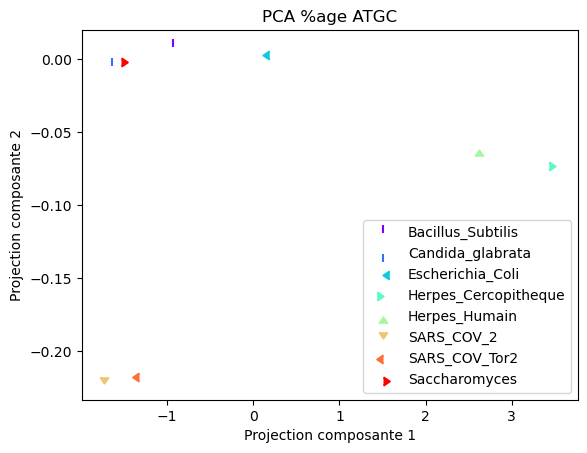

In [19]:
import matplotlib

fig, ax = plt.subplots()

ax.set_xlabel("Projection composante 1")
ax.set_ylabel("Projection composante 2")
ax.set_title("PCA %age ATGC")
cols = matplotlib.colormaps['rainbow'].resampled(8)
for x, y, num in zip(proj1, proj2, range(8)):
    ax.scatter(x, y, marker=num+2, color=cols(num), label=list_of_genomes[num])
ax.legend()